In [ ]:
import numpy as np

npy_path = '/data/coding/upload-data/data/mvsec/outdoor_day1/voxels/00000.npy'

data = np.load(npy_path)
print(data.shape)

In [ ]:
import cv2
p = "/data_nvme/sph/mvsec_processed/outdoor_day1/images/00000.png"
image = cv2.imread(p)
print(image.shape)
# print(image)

In [2]:
import cv2
import numpy as np

In [4]:
i = "/data_nvme/sph/mvsec_processed/outdoor_day1/images/00000.png"
v = "/data_nvme/sph/mvsec_processed/outdoor_day1/voxels/00000.npy"
d = "/data_nvme/sph/mvsec_processed/outdoor_day1/depths/00000.npy"

# img = cv2.imread(i)
# dep = np.load(d)
# vox = np.load(v)

# print(img.shape, dep.shape, vox.shape)
# dep = dep[np.isfinite(dep)]
# print(dep.shape)

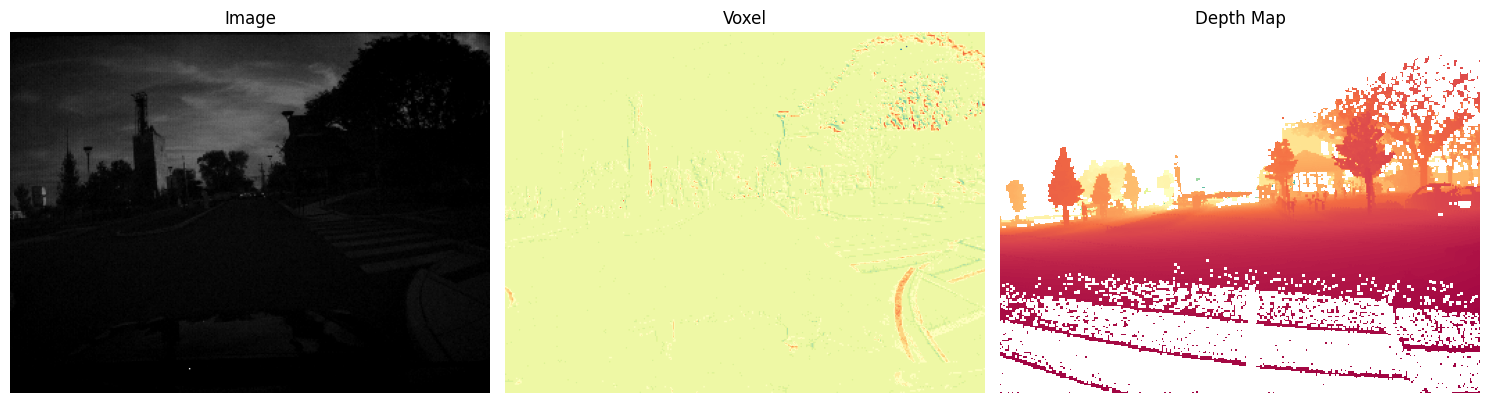

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from PIL import Image

def visualize_scene_from_paths(img_path, vox_path, dep_path):
    """
    Visualizes an image, voxel grid, and depth map from file paths.
    
    Parameters:
        img_path (str): Path to the image file (e.g., PNG).
        vox_path (str): Path to the voxel grid file (NumPy .npy file, shape [3, h, w]).
        dep_path (str): Path to the depth map file (NumPy .npy file, shape [h, w]).
    """
    # Load the image
    img = np.array(Image.open(img_path))
    # Load the voxel grid and transpose to [h, w, 3] for visualization
    vox = np.load(vox_path).transpose(1, 2, 0)
    
    # Load the depth map
    dep = np.load(dep_path)
    
    # Plotting
    fig = plt.figure(figsize=(15, 5))
    
    # 1. Display the image
    assert not np.isnan(img).any(), "Image contains NaN values"
    ax1 = fig.add_subplot(131)
    if img.ndim == 3:  # Color image
        ax1.imshow(img)
    else:  # Grayscale image
        ax1.imshow(img, cmap='gray')
    ax1.set_title('Image')
    ax1.axis('off')
    
    # 2. Display the voxel grid
    # ax2 = fig.add_subplot(132)
    # vox = (vox - vox.min()) / (vox.max() - vox.min()) * 255.0
    # vox = vox.astype(np.uint8)
    # assert not np.isnan(vox).any(), "Voxel grid contains NaN values"
    # ax2.imshow(vox)
    # ax2.set_title('Voxel')
    # ax2.axis('off')
    vox = vox.transpose(2, 0, 1)
    vox = vox[0] + vox[1] + vox[2]
    vox = vox - vox.min()
    
    ax2 = fig.add_subplot(132)
    im = ax2.imshow(vox, cmap='Spectral')
    ax2.set_title('Voxel')
    ax2.axis('off')
    # fig.colorbar(im, ax=ax2, orientation='vertical')
    # print(vox.shape, dep.shape)


    # 3. Display the depth map
    # dep[np.isnan(dep)] = 0
    # dep = np.clip(dep, 1.97, 80)
    # # dep = (dep - dep.min()) / (dep.max() - dep.min()) * 255.0
    # dep = dep.astype(np.uint8)
    # assert not np.isnan(dep).any(), "Depth map contains NaN values"
    # ax3 = fig.add_subplot(133)
    # im = ax3.imshow(dep, cmap='viridis')
    # ax3.set_title('Depth Map')
    # ax3.axis('off')
    # # fig.colorbar(im, ax=ax3, orientation='vertical')
    ax3 = fig.add_subplot(133)
    im = ax3.imshow(dep, cmap='viridis')
    ax3.set_title('Depth Map')
    ax3.axis('off')
    # fig.colorbar(im, ax=ax3, orientation='vertical')
    
    plt.tight_layout()
    plt.show()

# Example usage:
visualize_scene_from_paths(i, v, d)


#### Vis npy

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def vis_3_channel(arr):
    image = np.transpose(arr, (1, 2, 0))
    image = (image - image.min()) / (image.max() - image.min()) * 255.0
    image = image.astype(np.uint8)

    # Visualize
    plt.imshow(image)
    plt.axis('off')  # Turn off axis for better visualization
    plt.show()

def vis_1_channel(arr):
    arr = (arr - arr.min()) / (arr.max() - arr.min()) * 255.0
    arr = arr.astype(np.uint8)
    # Visualize with Spectral_r colormap
    plt.imshow(arr, cmap='Spectral_r')  # Use 'Spectral_r' colormap for the visualization
    plt.axis('off')  # Turn off axis for better visualization
    plt.show()


In [ ]:
dpt = np.load('/home/sph/event/da2-prompt-tuning/results/mvsec_metric_disp_vitl_day1_1/npy/00000.npy')
print(dpt.shape)
dpt[np.isnan(dpt)] = 0
dpt[np.isinf(dpt)] = 80
dpt = np.clip(dpt, 1.97, 80)
print(dpt.min(), dpt.max())
vis_1_channel(dpt)

In [86]:
dpt_path = r"F:\MVSEC\mvsec-hdf5\test\outdoor_day1\depths\00000.npy"
vox_path = r"F:\MVSEC\mvsec-hdf5\test\outdoor_day1\voxels\00000.npy"
img_path = r"F:\MVSEC\mvsec-hdf5\test\outdoor_day1\images\00000.png"

dpt = np.load(dpt_path)
MAX_DEPTH = 80
MIN_DEPTH = 1.97041
dpt[np.isnan(dpt)] = 0
dpt = np.clip(dpt, MIN_DEPTH, MAX_DEPTH)
vox = np.load(vox_path)

In [ ]:
reg_factor, clip_diatance = 3.70378, 80
prediction = 0
prediction = np.exp(reg_factor * (prediction - 1))
print(prediction * clip_diatance)

In [ ]:
print(dpt.shape, dpt.min(), dpt.max())
print(vox.shape, vox.min(), vox.max())

In [ ]:
vis_1_channel(dpt)

In [ ]:
vis_3_channel(vox)

In [ ]:
import cv2

def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.float32)

def gray2rgb(gray):
    return np.stack((gray,) * 3, axis=-1)

img_path = r"C:\Users\18562\Desktop\tmp_data_d4a6d490-fb9e-4a50-9a48-b0d0d75d5a1f.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) / 255.0

print(image.shape)
# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis
plt.show()

In [ ]:
# image = rgb2gray(image)
# print(image.shape)
# image = np.stack((image,)*3, axis=-1)
image = gray2rgb(rgb2gray(image))
print(image.shape)
# Display the image
plt.imshow(image)
plt.axis('off')  # Turn off the axis
plt.show()

In [ ]:
def normalize_voxelgrid(event_tensor):
    mask = np.nonzero(event_tensor)
    if mask[0].size > 0:
        mean, stddev = event_tensor[mask].mean(), event_tensor[mask].std()
        if stddev > 0:
            event_tensor[mask] = (event_tensor[mask] - mean) / stddev
    return event_tensor

print(vox.min(), vox.max(), vox.mean(), vox.std())
vox = normalize_voxelgrid(vox)
mask = np.nonzero(vox)
print(vox[mask].min(), vox[mask].max(), vox[mask].mean(), vox[mask].std())


#### Generate DENSE split file

In [2]:
import os

In [4]:
def get_files_in_dir(dir, file_types=['png', 'npy']):
    files = os.listdir(dir)
    files = [path for path in files if path.endswith((".png", ".npy"))]
    files.sort()
    files = [os.path.join(dir, path) for path in files]
    return files

In [18]:
data_root = '/data/coding/upload-data/data/DENSE/val'
towns = os.listdir(data_root)

rgbs, depths, events = [], [], []

for town in towns:
    rgb_dir = os.path.join(data_root, town, 'rgb', 'frames')
    depth_dir = os.path.join(data_root, town, 'depth', 'data')
    event_dir = os.path.join(data_root, town, 'events', 'voxels')
    
    rgb_name = get_files_in_dir(rgb_dir)
    depth_name = get_files_in_dir(depth_dir)
    event_name = get_files_in_dir(event_dir)
    
    rgbs = rgbs + rgb_name
    depths = depths + depth_name
    events = events + event_name

split_name = '/data/coding/upload-data/data/DENSE/val.txt'
lines = []

assert len(rgbs) == len(depths) and len(rgbs) == len(events)

for i in range(len(rgbs)):
    lines.append(rgbs[i] + ' ' + depths[i] + ' ' + events[i] + '\n')

with open(split_name, 'w') as f:
    f.writelines(lines)

In [6]:
data_root = '/data/coding/upload-data/data/DENSE/test'

rgb_dir = os.path.join(data_root, 'rgb', 'frames')
depth_dir = os.path.join(data_root, 'depth', 'data')
event_dir = os.path.join(data_root, 'events', 'voxels')

rgb_name = get_files_in_dir(rgb_dir)
depth_name = get_files_in_dir(depth_dir)
event_name = get_files_in_dir(event_dir)

split_name = '/data/coding/upload-data/data/DENSE/test.txt'
lines = []

assert len(rgb_name) == len(depth_name) and len(rgb_name) == len(event_name)

for i in range(len(rgb_name)):
    lines.append(rgb_name[i] + ' ' + depth_name[i] + ' ' + event_name[i] + '\n')

with open(split_name, 'w') as f:
    f.writelines(lines)

#### Delete redundant files in EventScape

In [ ]:
import os
import shutil

In [ ]:
data_root = '/data/coding/upload-data/data/EventScape/Town05_val'

towns = os.listdir(data_root)

for town in towns:
    town_path = os.path.join(data_root, town)
    sequences = os.listdir(town_path)
    for seq in sequences:
        seq_path = os.path.join(town_path, seq)
        
        depth_frames = os.path.join(seq_path, 'depth', 'frames')
        event_frames = os.path.join(seq_path, 'events', 'frames')
        semantic = os.path.join(seq_path, 'semantic')
        vehicles = os.path.join(seq_path, 'vehicle_data')

        if os.path.isdir(depth_frames):
            shutil.rmtree(depth_frames)
            
        if os.path.isdir(event_frames):
            shutil.rmtree(event_frames)
        
        if os.path.isdir(semantic):
            shutil.rmtree(semantic)
        
        if os.path.isdir(vehicles):
            shutil.rmtree(vehicles)

In [ ]:
''' Calculate the mean and std of MVSEC '''
from PIL import Image
import numpy as np
import os

def calculate_mean_and_std(image_paths):
    # 初始化累计均值和方差
    mean = 0.0
    std = 0.0
    n_images = len(image_paths)
    
    # 首先计算所有图像的平均值
    for img_path in image_paths:
        img = Image.open(img_path).convert('L')  # 确保图像是灰度模式
        img_np = np.array(img, dtype=np.float32) / 255.0
        mean += img_np.mean()
    mean = mean / n_images
    
    # 接着计算所有图像的标准差
    for img_path in image_paths:
        img = Image.open(img_path).convert('L')
        img_np = np.array(img, dtype=np.float32) / 255.0
        std += ((img_np - mean) ** 2).mean()
    std = np.sqrt(std / n_images)
    
    return mean, std

dir = '/data/coding/code/da2-prompt-tuning/dataset/splits/mvsec'
split_files = os.listdir(dir)

image_paths = []
for split in split_files:
    txt_path = os.path.join(dir, split)
    with open(txt_path, 'r') as f:
        lines = f.readlines()
    lines = [line.split(' ')[0] for line in lines]
    image_paths.extend(lines)

mean, std = calculate_mean_and_std(image_paths)
print(mean, std)

### EventScape events

In [44]:
import numpy as np

In [ ]:
p = '/data/coding/upload-data/data/EventScape/Town05_val/Town05/sequence_8/events/data/05_008_0001_events.npz'
data = np.load(p)
print(data)

In [ ]:
x = data['x']
y = data['y']
p = data['p']
t = data['t']
print(x.shape, y.shape, p.shape, t.shape)

In [ ]:
combined_array = np.vstack((t, x, y, p)).T
print(combined_array.shape)
print(combined_array[0])

#### Delete redundant files in dense

In [1]:
import os
import shutil

In [4]:
data_root = '/data/coding/upload-data/data/EventScape/Town05_val'

towns = os.listdir(data_root)

for town in towns:
    town_path = os.path.join(data_root, town)
    sequences = os.listdir(town_path)
    for seq in sequences:
        seq_path = os.path.join(town_path, seq)
        
        depth_frames = os.path.join(seq_path, 'depth', 'frames')
        event_frames = os.path.join(seq_path, 'events', 'frames')
        semantic = os.path.join(seq_path, 'semantic')
        vehicles = os.path.join(seq_path, 'vehicle_data')

        if os.path.isdir(depth_frames):
            shutil.rmtree(depth_frames)
            
        if os.path.isdir(event_frames):
            shutil.rmtree(event_frames)
        
        if os.path.isdir(semantic):
            shutil.rmtree(semantic)
        
        if os.path.isdir(vehicles):
            shutil.rmtree(vehicles)

In [10]:
test_dir = '/data/coding/upload-data/data/DENSE/test'
depth_frames = os.path.join(test_dir, 'depth', 'frames')
event_frames = os.path.join(test_dir, 'events', 'frames')
semantic = os.path.join(test_dir, 'semantic')

shutil.rmtree(depth_frames)
shutil.rmtree(event_frames)
shutil.rmtree(semantic)

In [ ]:
import numpy as np
import cv2
npy_path = '/data/coding/upload-data/data/DENSE/test/events/voxels/event_tensor_0000000000.npy'

data = np.load(npy_path)
print(data.shape)
data = data.transpose(1, 2, 0)
print(data.shape)

In [ ]:
data = cv2.resize(data, (518, 686), interpolation=cv2.INTER_NEAREST)
print(data.shape)

In [51]:
def prepare_depth(depth, reg_factor, d_max):
    # Normalize depth
    # depth = np.clip(depth, 0.0, d_max)
    depth = depth / d_max
    depth = np.log(depth + 1e-6) / reg_factor + 1.0
    # depth = depth.clip(0.0, 1.0)
    return depth

In [ ]:
depth = np.array([0, -1, 80, 1000, 1200])
reg_factor, d_max = 6.2044, 1000
depth = prepare_depth(depth, reg_factor, d_max)
print(depth)
mask = (depth >= 0)
print(mask)

#### Process MVSEC(hdf5)

* `uint8`: `<HDF5 dataset "image_raw": shape (11937, 260, 346), type "|u1">`
* `float64`: `<HDF5 dataset "image_raw_ts": shape (11937,), type "<f8">`
* `float32`: `<HDF5 dataset "depth_image_raw": shape (5134, 260, 346), type "<f4">`
* `float64`: `<HDF5 dataset "events": shape (105874257, 4), type "<f8">`


In [12]:
from tqdm import tqdm

import json
import numpy as np
from PIL import Image

import h5py
import os

In [13]:
def map_depth_to_image(image_ts, depth_ts, output_dir):
    """
    Map depth timestamps to the nearest previous image timestamps.
    
    Args:
        image_ts (numpy.ndarray): timestamps of each image.
        depth_ts (numpy.ndarray): timestamps of each depth.
        output_dir (str): Directory to save the output JSON files.
        
    Output:
        Saves two JSON files:
        - depth_to_image.json: Mapping from depth indices to nearest image indices.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Create mappings
    depth_to_image = {}

    image_idx = 0
    # Compute nearest previous image for each depth
    for depth_idx, depth_time in enumerate(depth_ts):
        # nearest_image_idx = None
        # for idx, ts in enumerate(image_ts):
        #     if ts > depth_time:
        #         break
        #     nearest_image_idx = idx
        # nearest_image_idx = nearest_image_idx if nearest_image_idx is not None else len(image_ts) - 1
        
        # Compute nearest image for each depth
        while image_idx < len(image_ts) - 1 and abs(image_ts[image_idx + 1] - depth_time) < abs(image_ts[image_idx] - depth_time):
            image_idx += 1
        nearest_image_idx = image_idx
        
        item = {}
        item['nearest_img_idx'] = nearest_image_idx
        item['depth_ts'] = depth_time
        item['img_ts'] = image_ts[nearest_image_idx]
        item['diff'] = abs(item['depth_ts'] - item['img_ts'])
        
        depth_to_image[depth_idx] = item

    # Save mappings to JSON files
    with open(f"{output_dir}/depth_to_image.json", "w") as f:
        json.dump(depth_to_image, f, indent=4)

    print(f"Mapping saved to {output_dir}/depth_to_image.json")
    return depth_to_image

In [40]:
def map_depth_to_events(depth_ts, events, output_dir):
    """
    Maps each depth map timestamp to a range of events within a specific time window.

    Parameters:
        depth_ts (numpy.ndarray): timestamps of each depth map.
        events (numpy.ndarray): each row represents an event as (x, y, timestamp, p).
        output_dir (str): Directory to save the output JSON file.

    Output:
        A JSON file saved to output_dir containing the correspondence between depth maps and events.
    """
    
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Initialize result dictionary
    depth_to_events_mapping = {}

    # Start index for events
    current_event_index = 0

    # Iterate through each depth timestamp
    for i, depth_time in enumerate(depth_ts):
        # Move the start index forward to skip past events older than 50ms before the depth timestamp
        while current_event_index < len(events) and events[current_event_index, 2] < depth_time - 0.05:
            current_event_index += 1

        print(current_event_index, depth_time, events[current_event_index, 2])
        # Find the closest event index before the depth timestamp
        end_event_index = current_event_index
        while end_event_index < len(events) and events[end_event_index, 2] <= depth_time:
            end_event_index += 1

        if current_event_index < len(events) and end_event_index > current_event_index:
            # Save the mapping
            depth_to_events_mapping[i] = {
                "depth_timestamp": float(depth_time),
                "start_event_index": int(current_event_index),
                "end_event_index": int(end_event_index - 1),
                "start_event_timestamp": float(events[current_event_index, 2]),
                "end_event_timestamp": float(events[end_event_index - 1, 2])
            }

    # Save the mapping to a JSON file
    # output_file = os.path.join(output_dir, "depth_to_events_mapping.json")
    # with open(output_file, "w") as f:
    #     json.dump(depth_to_events_mapping, f, indent=4)

    # print(f"Mapping saved to {output_file}")
    return depth_to_events_mapping

In [15]:
def events_to_voxel_grid(events, num_bins, width, height):
    """
    Build a voxel grid with bilinear interpolation in the time domain from a set of events.

    :param events: a [N x 4] NumPy array containing one event per row in the form: [timestamp, x, y, polarity]
    :param num_bins: number of bins in the temporal axis of the voxel grid
    :param width, height: dimensions of the voxel grid
    """

    assert(events.shape[1] == 4)
    assert(num_bins > 0)
    assert(width > 0)
    assert(height > 0)

    voxel_grid = np.zeros((num_bins, height, width), np.float32).ravel()

    # normalize the event timestamps so that they lie between 0 and num_bins
    last_stamp = events[-1, 0]
    first_stamp = events[0, 0]
    deltaT = last_stamp - first_stamp

    if deltaT == 0:
        deltaT = 1.0
    #print("events 1", events[:,0])
    events[:, 0] = (num_bins - 1) * (events[:, 0] - first_stamp) / deltaT
    ts = events[:, 0]
    xs = events[:, 1].astype(np.int)
    ys = events[:, 2].astype(np.int)
    pols = events[:, 3]
    pols[pols == 0] = -1  # polarity should be +1 / -1

    tis = ts.astype(np.int)
    dts = ts - tis
    vals_left = pols * (1.0 - dts)
    vals_right = pols * dts

    valid_indices = tis < num_bins
    np.add.at(voxel_grid, xs[valid_indices] + ys[valid_indices] * width +
              tis[valid_indices] * width * height, vals_left[valid_indices])

    valid_indices = (tis + 1) < num_bins
    np.add.at(voxel_grid, xs[valid_indices] + ys[valid_indices] * width +
              (tis[valid_indices] + 1) * width * height, vals_right[valid_indices])

    voxel_grid = np.reshape(voxel_grid, (num_bins, height, width))

    return voxel_grid

In [16]:
def save_depths2dir(depths, selected_depths, output_dir):
    print("Saving depths to directory:", output_dir)
    for dpt_id in tqdm(selected_depths, desc="Saving depths"):
        dpt = depths[dpt_id]
        np.save(output_dir + '/%05d.npy' % dpt_id, dpt)
    print("Finished saving depths.")

def save_images2dir(images, selected_depths, depth2image, output_dir):
    print("Saving images to directory:", output_dir)
    for dpt_id in tqdm(selected_depths, desc="Saving images"):
        img_id = depth2image[dpt_id]["nearest_img_idx"]

        img = images[img_id]
        img = Image.fromarray(img)
        img.save(output_dir + '/%05d.png' % dpt_id)
    print("Finished saving images.")


def save_voxels2dir(
    events, selected_depths, depth2event, output_dir, num_bins=5, width=346, height=260
):
    print("Saving voxels to directory:", output_dir)
    for dpt_id in tqdm(selected_depths, desc="Saving voxels"):
        st_id = depth2event[dpt_id]["start_event_index"]
        en_id = depth2event[dpt_id]["end_event_index"]

        event_slice = events[st_id : en_id + 1]
        event_slice = event_slice[:, [2, 0, 1, 3]] # (x, y, t, p) --> (t, x, y, p)

        voxels = events_to_voxel_grid(event_slice, num_bins, width, height)
        np.save(output_dir + '/%05d.npy' % dpt_id, voxels)
    print("Finished saving voxels.")

In [17]:
def check_hdf5_data_struct(hdf5_file):
    def prt_name(name):
        print(name)

    hdf5_file.visit(prt_name)

In [ ]:
data_hdf5_path = "/data/coding/upload-data/data/mvsec_hdf5/outdoor_night2_data.hdf5"
gt_hdf5_path = "/data/coding/upload-data/data/mvsec_hdf5/outdoor_night2_gt.hdf5"

if os.path.isfile(data_hdf5_path):
    print(f"Data file {data_hdf5_path} exists")
if os.path.isfile(gt_hdf5_path):
    print(f"GT file {gt_hdf5_path} exists")

data = h5py.File(data_hdf5_path)
gt = h5py.File(gt_hdf5_path)

In [28]:
image_ts = data['davis']['left']['image_raw_ts']
events = data['davis']['left']['events'] # x, y, t, p
depth_image_raw_ts = gt['davis']['left']['depth_image_raw_ts']
images = data['davis']['left']['image_raw']
depth_image_raw = gt['davis']['left']['depth_image_raw']

In [29]:
image_ts = np.array(image_ts)
depth_image_raw_ts = np.array(depth_image_raw_ts)
events = np.array(events)

In [21]:
event_timestamps = events[:, 2]
if not np.all(event_timestamps[:-1] <= event_timestamps[1:]):
    print("Event timestamps are not in ascending order")

if not np.all(depth_image_raw_ts[:-1] <= depth_image_raw_ts[1:]):
    print("Depth timestamps are not in ascending order")

if not np.all(image_ts[:-1] <= image_ts[1:]):
    print("Image timestamps are not in ascending order")

In [ ]:
print(depth_image_raw_ts[0])
print(events[0][2])

In [ ]:
print(len(depth_image_raw_ts))
print(len(events))

In [ ]:
print(depth_image_raw_ts[0])
print(events[10000000][2])

In [ ]:
map_index_dir = '/data'
depth2image = map_depth_to_image(image_ts, depth_image_raw_ts, map_index_dir)
depth2event = map_depth_to_events(depth_image_raw_ts, events, map_index_dir)

In [ ]:
selected_depths = []

for depth_id, item in depth2image.items():
    diff = item["diff"]
    if diff * 1000 > 10:
        print(f"Depth {depth_id}: No recent image, discard the GT")
        continue

    if depth_id not in depth2event:
        print(f"Depth {depth_id}: There are not enough events, discard the GT")
        continue
    
    selected_depths.append(depth_id)

print(f"Length of selected samples: {len(selected_depths)}")

In [ ]:
depths_dir = os.path.join(map_index_dir, "depths")
images_dir = os.path.join(map_index_dir, "images")
events_dir = os.path.join(map_index_dir, "voxels")

os.makedirs(depths_dir, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)
os.makedirs(events_dir, exist_ok=True)